<a href="https://colab.research.google.com/github/dharmika-p/Medical-Triage/blob/main/MedicalTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install stable-baselines3==2.0.0
!pip install gymnasium
!pip install pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 23.2 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.3
    Uninstalling gymnasium-1.2.3:
      Successfully uninstalled gymnasium-1.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 which is incompatible.


In [29]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, DQN
from transformers import AutoTokenizer, AutoModel
import torch
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model_bert = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model_bert(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

def reduce_embedding(vec, size=10):
    return vec[:size]

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Testing.csv to Testing.csv
Saving Training.csv to Training.csv


In [13]:
train_df = pd.read_csv("Training.csv")
test_df = pd.read_csv("Testing.csv")

print(train_df.head())

   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  scurring  \
0       0           0             0        0                 0  ...         0   
1       0           0             0        0                 0  ...         0   
2       0           0             0        0                 0  ...         0   
3       0           0             0        0                 0  ...         0   
4       0           0             0        0                 0  ...         0   

   skin_peeling  silver_like_dusting  

In [58]:
for df in [train_df, test_df]:
    df["text"] = df["prognosis"]
    df["embedding"] = df["text"].apply(get_embedding)


In [59]:
def severity_map(disease):
    critical = ["Heart attack", "Stroke", "Cancer"]
    medium = ["Pneumonia", "Tuberculosis"]

    if disease in critical:
        return 5
    elif disease in medium:
        return 3
    else:
        return 1

for df in [train_df, test_df]:
    df["severity"] = df["prognosis"].apply(severity_map)
    df["waiting_time"] = [random.randint(1,20) for _ in range(len(df))]
    df["risk"] = df["severity"].apply(lambda x: 2 if x>=4 else 1 if x>=2 else 0)


In [60]:
class TriageEnv(gym.Env):
    def __init__(self, data):
        super().__init__()
        self.data = data
        self.queue_size = 5

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=-10, high=10, shape=(14,), dtype=np.float32)

        self.prev_action = 0

    def reset(self, seed=None, options=None):
        self.queue = self.data.sample(self.queue_size).to_dict("records")
        self.current = self.queue.pop(0)
        self.prev_action = 0
        return self.get_state(), {}

    def get_state(self):
        emb = reduce_embedding(self.current["embedding"])

        # Partial observability
        if random.random() < 0.3:
            waiting_time = 0
        else:
            waiting_time = self.current["waiting_time"]

        return np.concatenate([
            emb,
            [
                self.current["severity"],
                waiting_time,
                self.current["risk"],
                self.prev_action
            ]
        ]).astype(np.float32)

    def step(self, action):
        severity = self.current["severity"]
        waiting = self.current["waiting_time"]

        # Reward logic
        if severity >= 4 and action == 2:
            reward = 10
        elif severity >= 4 and action != 2:
            reward = -20
        elif severity <= 2 and action == 2:
            reward = -5
        else:
            reward = 5

        # Safety penalty (strong)
        if severity >= 4 and action != 2:
            reward -= 50

        reward -= 0.2 * waiting

        self.prev_action = action

        terminated = False
        truncated = False

        if len(self.queue) == 0:
            terminated = True
        else:
            self.current = self.queue.pop(0)

        return self.get_state(), reward, terminated, truncated, {}

In [61]:
env = TriageEnv(train_df)

In [62]:
ppo_model = PPO("MlpPolicy", env, verbose=0)
dqn_model = DQN("MlpPolicy", env, verbose=0)

ppo_model.learn(total_timesteps=15000)
dqn_model.learn(total_timesteps=15000)

In [63]:
def evaluate_rewards(model, env):
    rewards = []
    obs, _ = env.reset()

    for _ in range(100):
        action, _ = model.predict(obs)
        obs, reward, done, _, _ = env.step(action)
        rewards.append(reward)

        if done:
            obs, _ = env.reset()

    return rewards


def safety_violations(model, env):
    violations = 0
    counts = []
    obs, _ = env.reset()

    for _ in range(100):
        action, _ = model.predict(obs)

        if env.current["severity"] >= 4 and action != 2:
            violations += 1

        counts.append(violations)

        obs, _, done, _, _ = env.step(action)

        if done:
            obs, _ = env.reset()

    return counts


def action_distribution(model, env):
    actions = []
    obs, _ = env.reset()

    for _ in range(100):
        action, _ = model.predict(obs)
        actions.append(action)

        obs, _, done, _, _ = env.step(action)

        if done:
            obs, _ = env.reset()

    return actions

In [64]:
ppo_rewards = evaluate_rewards(ppo_model, env)
dqn_rewards = evaluate_rewards(dqn_model, env)

ppo_safe = safety_violations(ppo_model, env)
dqn_safe = safety_violations(dqn_model, env)

ppo_actions = action_distribution(ppo_model, env)
dqn_actions = action_distribution(dqn_model, env)


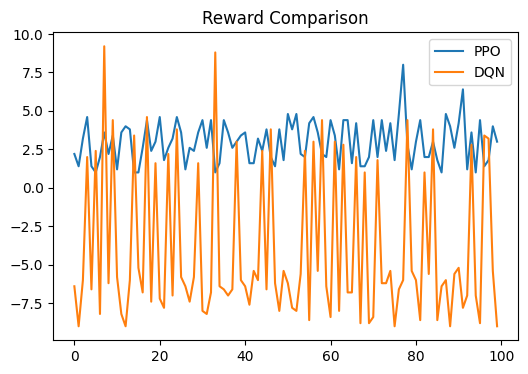

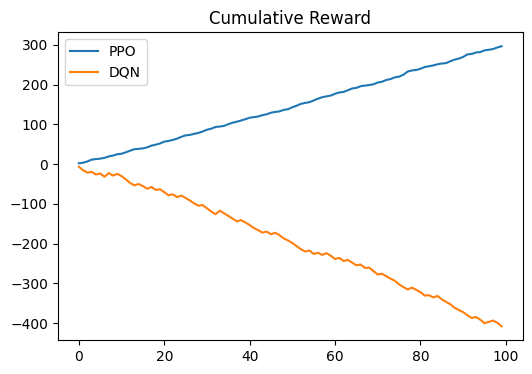

In [65]:
# Reward Comparison
plt.figure(figsize=(6,4))
plt.plot(ppo_rewards, label="PPO")
plt.plot(dqn_rewards, label="DQN")
plt.title("Reward Comparison")
plt.legend()
plt.show()

# Cumulative Reward
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(ppo_rewards), label="PPO")
plt.plot(np.cumsum(dqn_rewards), label="DQN")
plt.title("Cumulative Reward")
plt.legend()
plt.show()



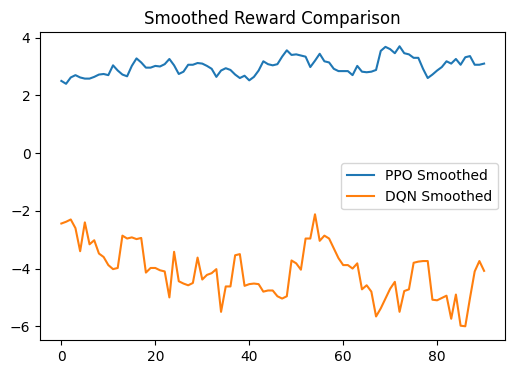

In [66]:
# Smoothed Rewards
def smooth(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(6,4))
plt.plot(smooth(ppo_rewards), label="PPO Smoothed")
plt.plot(smooth(dqn_rewards), label="DQN Smoothed")
plt.title("Smoothed Reward Comparison")
plt.legend()
plt.show()

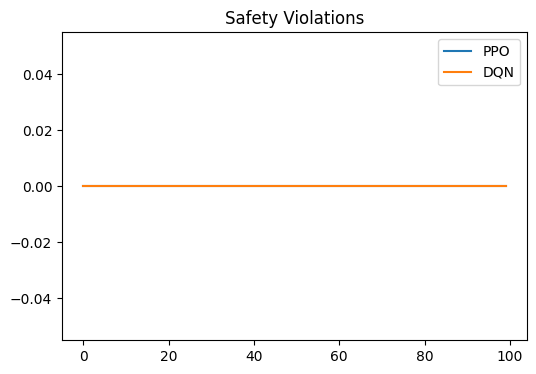

In [69]:
# Safety Violations
plt.figure(figsize=(6,4))
plt.plot(ppo_safe, label="PPO")
plt.plot(dqn_safe, label="DQN")
plt.title("Safety Violations")
plt.legend()
plt.show()

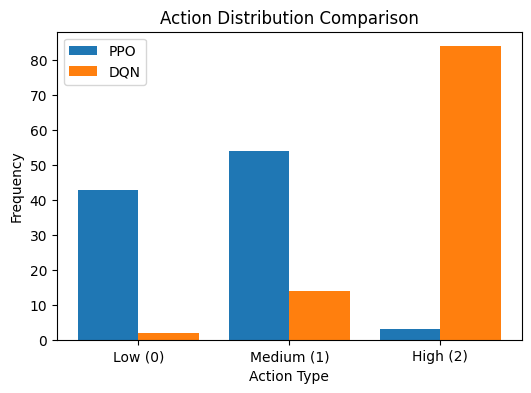

In [70]:
# Action Distribution (BAR)
ppo_counts = np.bincount(ppo_actions, minlength=3)
dqn_counts = np.bincount(dqn_actions, minlength=3)

x = np.arange(3)

plt.figure(figsize=(6,4))
plt.bar(x - 0.2, ppo_counts, width=0.4, label="PPO")
plt.bar(x + 0.2, dqn_counts, width=0.4, label="DQN")

plt.xticks(x, ["Low (0)", "Medium (1)", "High (2)"])
plt.xlabel("Action Type")
plt.ylabel("Frequency")
plt.title("Action Distribution Comparison")
plt.legend()
plt.show()

In [71]:
print("===== FINAL METRICS =====")
print("PPO Avg Reward:", np.mean(ppo_rewards))
print("DQN Avg Reward:", np.mean(dqn_rewards))

print("PPO Violations:", ppo_safe[-1])
print("DQN Violations:", dqn_safe[-1])

===== FINAL METRICS =====
PPO Avg Reward: 2.9659999999999997
DQN Avg Reward: -4.080000000000001
PPO Violations: 0
DQN Violations: 0
